# Tesla Deliveries ML Pipeline (2015–2025)

## Week 2 Assignment — Build an end-to-end ML pipeline on sales/price data.

**End-to-End Machine Learning Pipeline**  
Topics covered: Data Preprocessing · EDA · Feature Engineering · Regression Modeling · Hyperparameter Tuning · Time Series Forecasting

---
**Dataset:** `tesla_deliveries_dataset_2015_2025.csv` — 2,640 records across 5 models, 4 regions, 2015–2025.  
**Target variables:**  
- *Regression*: `Avg_Price_USD`  
- *Forecasting*: `Estimated_Deliveries` (monthly time series)


## 0. Library Imports & Configuration

In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Display config
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})

print(" All libraries loaded successfully!")


 All libraries loaded successfully!


## 1. Data Loading & First Look

In [37]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names : {df.columns.tolist()}")
df.head(8)


Shape : 2,640 rows × 12 columns

Column names : ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,"92,874.27",120,704,"1,863.42",Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,"62,205.65",75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,"117,887.32",82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,"89,294.91",120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,"114,846.78",120,661,"1,226.88",Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,"86,930.57",82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,"87,588.21",82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,"73,815.61",100,592,746.81,Official (Quarter),8216


In [38]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [39]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','min','max'])


,count,mean,std,min,25%,50%,75%,max
Year,2640.000000,2020.000000,3.162877,2015.000000,2017.000000,2020.000000,2023.000000,2025.000000
Month,2640.000000,6.500000,3.452707,1.000000,3.750000,6.500000,9.250000,12.000000
Estimated_Deliveries,2640.000000,9922.199621,3935.950093,48.000000,7292.000000,9857.000000,12510.250000,25704.000000
Production_Units,2640.000000,10655.847348,4260.600858,50.000000,7828.250000,10546.500000,13469.000000,28939.000000
Avg_Price_USD,2640.000000,84907.340330,20123.258036,50003.700000,67726.365000,85058.510000,102373.042500,119965.360000
Battery_Capacity_kWh,2640.000000,87.059470,20.836265,60.000000,75.000000,82.000000,100.000000,120.000000
Range_km,2640.000000,500.257576,120.868549,330.000000,418.000000,470.000000,586.250000,719.000000
CO2_Saved_tons,2640.000000,744.076989,353.221224,3.070000,499.620000,699.515000,943.765000,2548.550000
Charging_Stations,2640.000000,8932.133712,3469.565883,3002.000000,5897.750000,8901.500000,11938.000000,14996.000000


## 2. Data Preprocessing
### 2.1 Missing Values & Duplicates

In [40]:
# ── Missing values ──
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")

# ── Duplicates ──
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")


Missing values per column:
 No missing values found!

Duplicate rows: 0


### 2.2 Data Types & Basic Cleaning

In [41]:
# Create a clean working copy
df_clean = df.copy()

# Verify dtypes — cast just in case
df_clean['Year']  = df_clean['Year'].astype(int)
df_clean['Month'] = df_clean['Month'].astype(int)

# Create a proper datetime column for time-series work
df_clean['Date'] = pd.to_datetime(
    df_clean['Year'].astype(str) + '-' + df_clean['Month'].astype(str).str.zfill(2) + '-01'
)

print(" Cleaned dataframe shape:", df_clean.shape)
print("Date range:", df_clean['Date'].min().strftime('%b %Y'), "→", df_clean['Date'].max().strftime('%b %Y'))
df_clean[['Date','Year','Month','Region','Model']].head(5)


 Cleaned dataframe shape: (2640, 13)
Date range: Jan 2015 → Dec 2025


,Date,Year,Month,Region,Model
0,2023-05-01,2023,5,Europe,Model S
1,2015-02-01,2015,2,Asia,Model X
2,2019-01-01,2019,1,North America,Model X
3,2021-02-01,2021,2,North America,Model 3
4,2016-12-01,2016,12,Middle East,Model Y


### 2.3 Outlier Detection (IQR method)

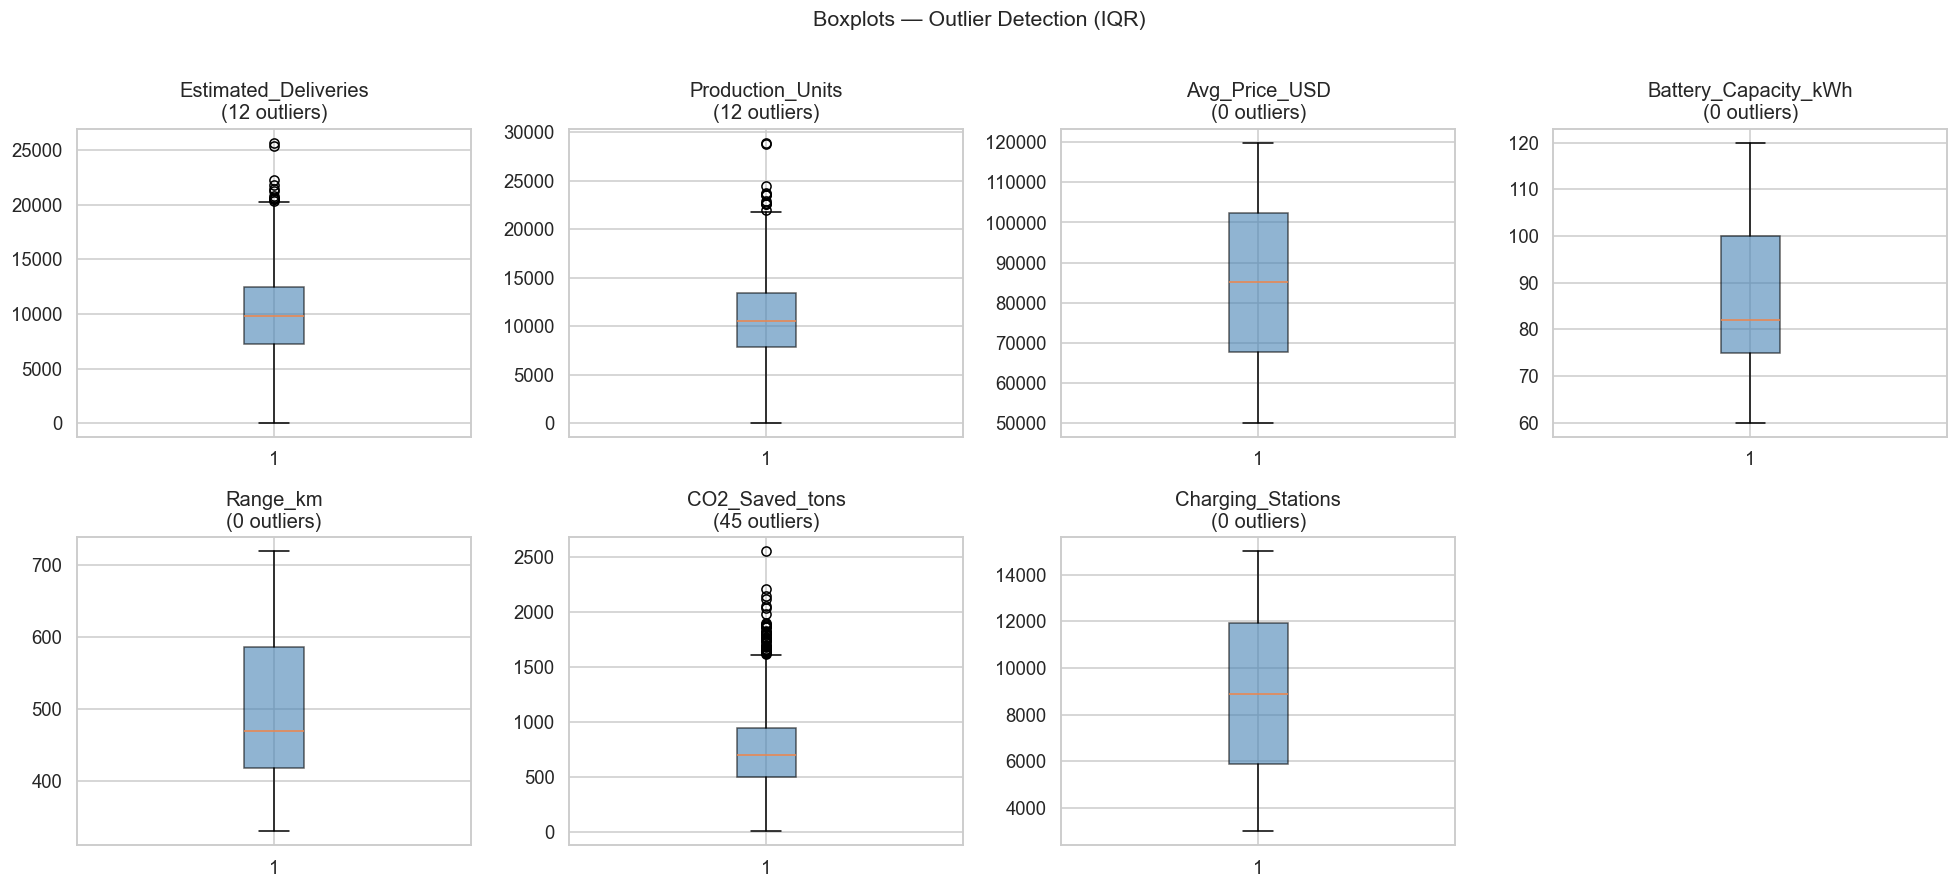


Outlier counts (IQR method):
  Estimated_Deliveries        : 12
  Production_Units            : 12
  Avg_Price_USD               : 0
  Battery_Capacity_kWh        : 0
  Range_km                    : 0
  CO2_Saved_tons              : 45
  Charging_Stations           : 0


In [42]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(numeric_cols):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    outlier_summary[col] = n_out
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}\n({n_out} outliers)')
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.suptitle('Boxplots — Outlier Detection (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nOutlier counts (IQR method):")
for k,v in outlier_summary.items():
    print(f"  {k:<28}: {v}")


### 2.4 Encoding Categorical Variables

In [43]:
df_ml = df_clean.copy()

# Label-encode Region and Model (low cardinality)
le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df_ml['Region_enc']      = le_region.fit_transform(df_ml['Region'])
df_ml['Model_enc']       = le_model.fit_transform(df_ml['Model'])
df_ml['Source_Type_enc'] = le_source.fit_transform(df_ml['Source_Type'])

# One-hot encode for comparison (useful later)
df_ohe = pd.get_dummies(df_ml, columns=['Region','Model','Source_Type'], drop_first=True)

print("Label encoder classes:")
print("  Region  :", le_region.classes_)
print("  Model   :", le_model.classes_)
print("  Source  :", le_source.classes_)
print("\ndf_ml shape (label encoded):", df_ml.shape)


Label encoder classes:
  Region  : ['Asia' 'Europe' 'Middle East' 'North America']
  Model   : ['Cybertruck' 'Model 3' 'Model S' 'Model X' 'Model Y']
  Source  : ['Estimated (Region)' 'Interpolated (Month)' 'Official (Quarter)']

df_ml shape (label encoded): (2640, 16)


## 3. Exploratory Data Analysis (EDA)
### 3.1 Distribution of Numeric Features

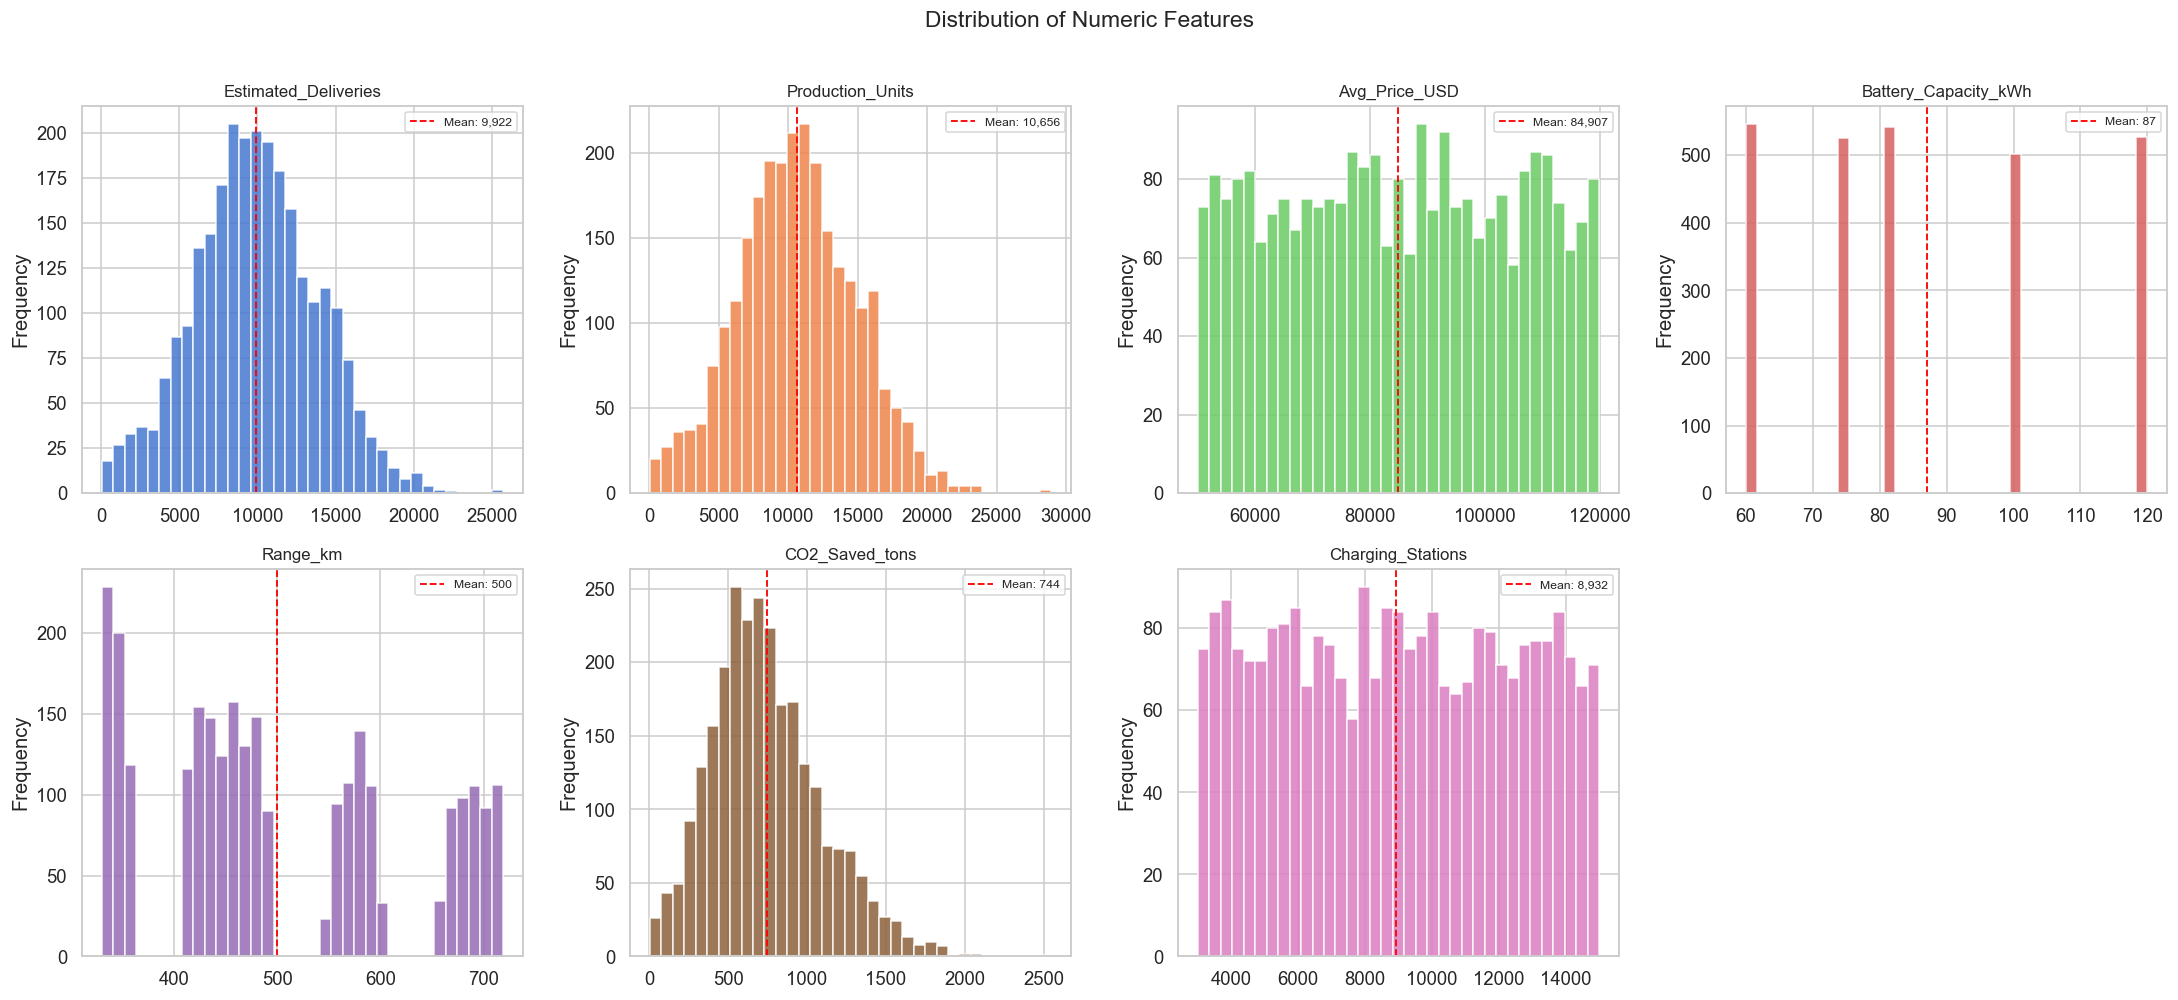

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
colors = sns.color_palette('muted', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_clean[col], bins=35, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frequency')
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:,.0f}')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distribution of Numeric Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


### 3.2 Deliveries by Model & Region

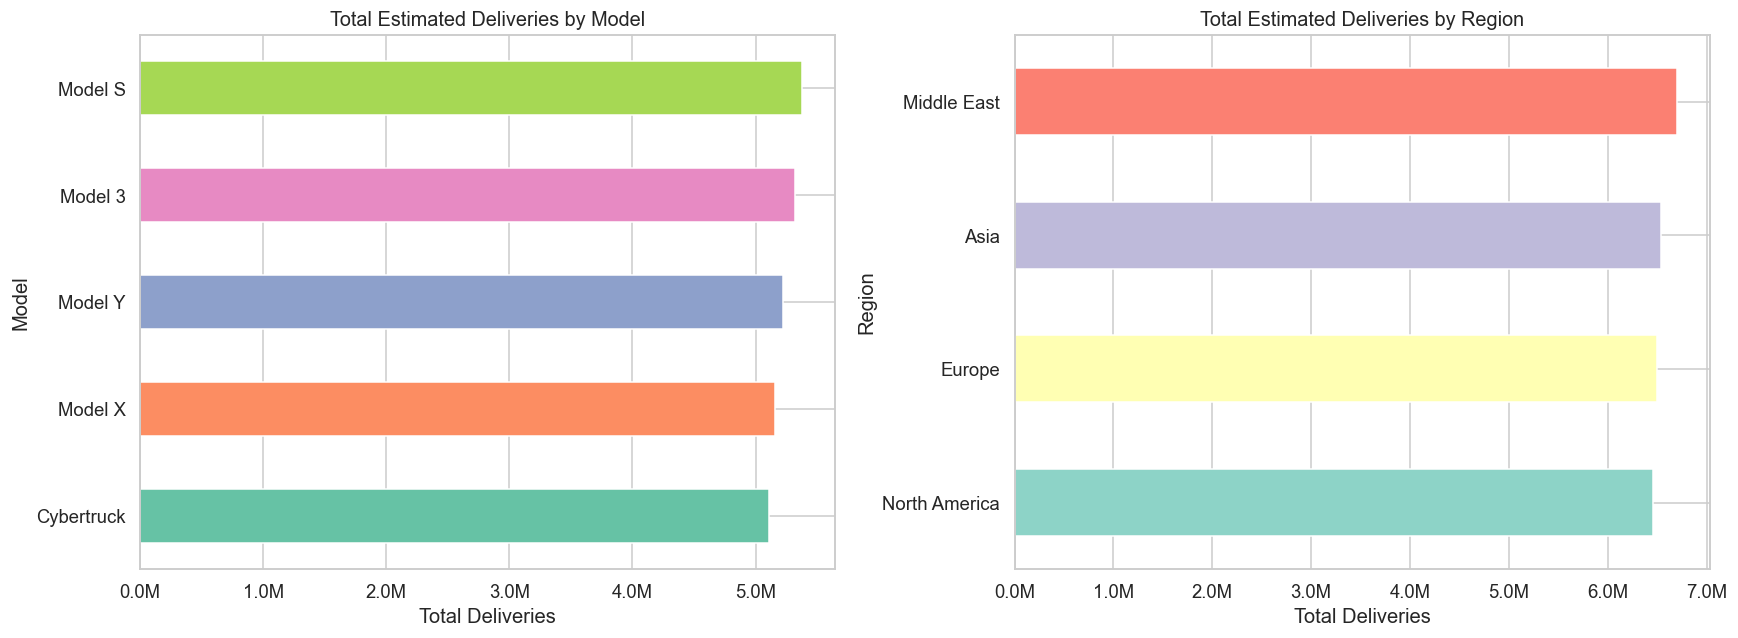

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Model
model_del = df_clean.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=True)
model_del.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', len(model_del)),
               edgecolor='white')
axes[0].set_title('Total Estimated Deliveries by Model', fontsize=13)
axes[0].set_xlabel('Total Deliveries')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# By Region
region_del = df_clean.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=True)
region_del.plot(kind='barh', ax=axes[1], color=sns.color_palette('Set3', len(region_del)),
                edgecolor='white')
axes[1].set_title('Total Estimated Deliveries by Region', fontsize=13)
axes[1].set_xlabel('Total Deliveries')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


### 3.3 Yearly Delivery Trend

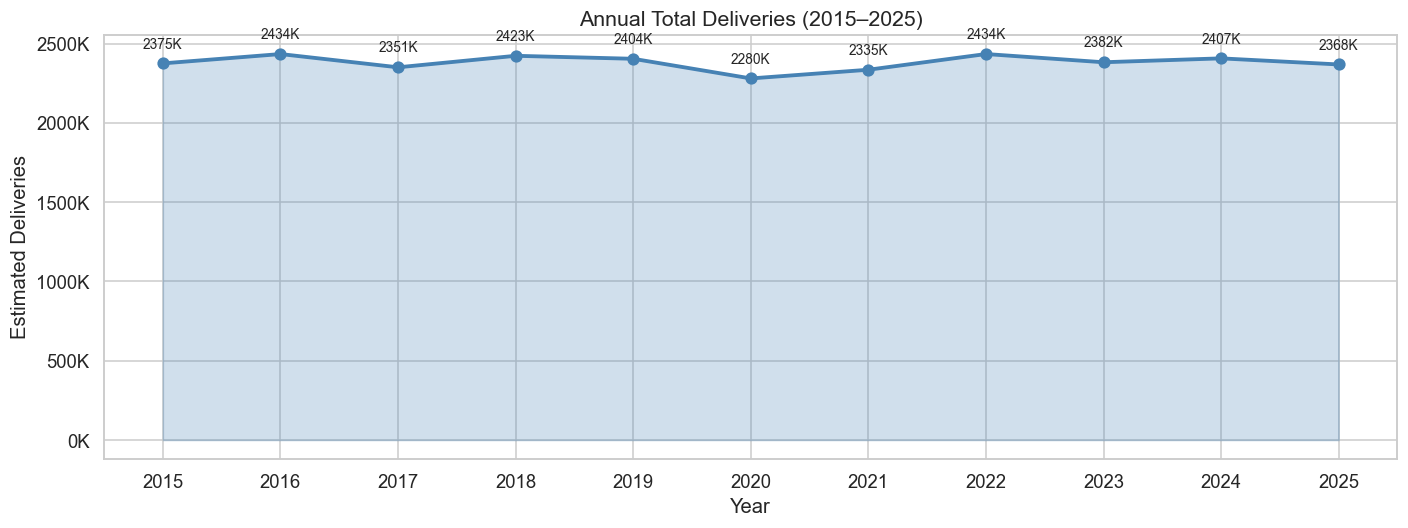

In [46]:
yearly = df_clean.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(yearly['Year'], yearly['Estimated_Deliveries'], alpha=0.25, color='steelblue')
ax.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', linewidth=2.5,
        color='steelblue', markersize=7)

for _, row in yearly.iterrows():
    ax.annotate(f"{row['Estimated_Deliveries']/1e3:.0f}K",
                (row['Year'], row['Estimated_Deliveries']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Annual Total Deliveries (2015–2025)', fontsize=14)
ax.set_xlabel('Year'); ax.set_ylabel('Estimated Deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.set_xticks(yearly['Year'])
plt.tight_layout(); plt.show()


### 3.4 Price Trend by Model

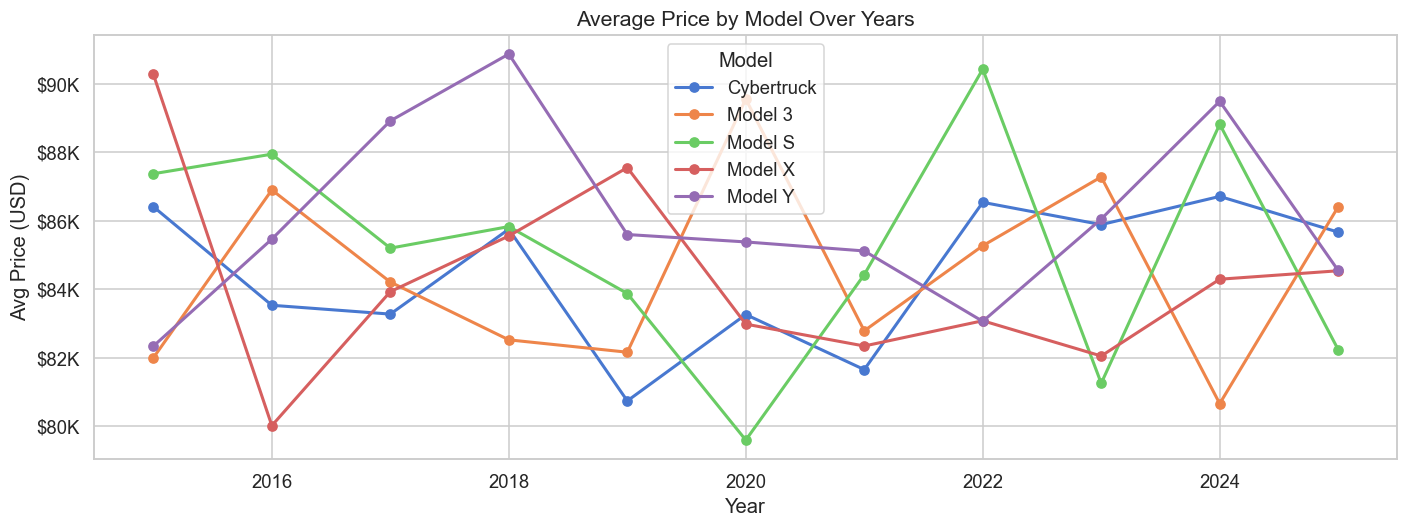

In [47]:
yearly_price = df_clean.groupby(['Year','Model'])['Avg_Price_USD'].mean().reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
for model in yearly_price['Model'].unique():
    sub = yearly_price[yearly_price['Model'] == model]
    ax.plot(sub['Year'], sub['Avg_Price_USD'], marker='o', linewidth=2, label=model)

ax.set_title('Average Price by Model Over Years', fontsize=14)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(title='Model')
plt.tight_layout(); plt.show()


### 3.5 Correlation Heatmap

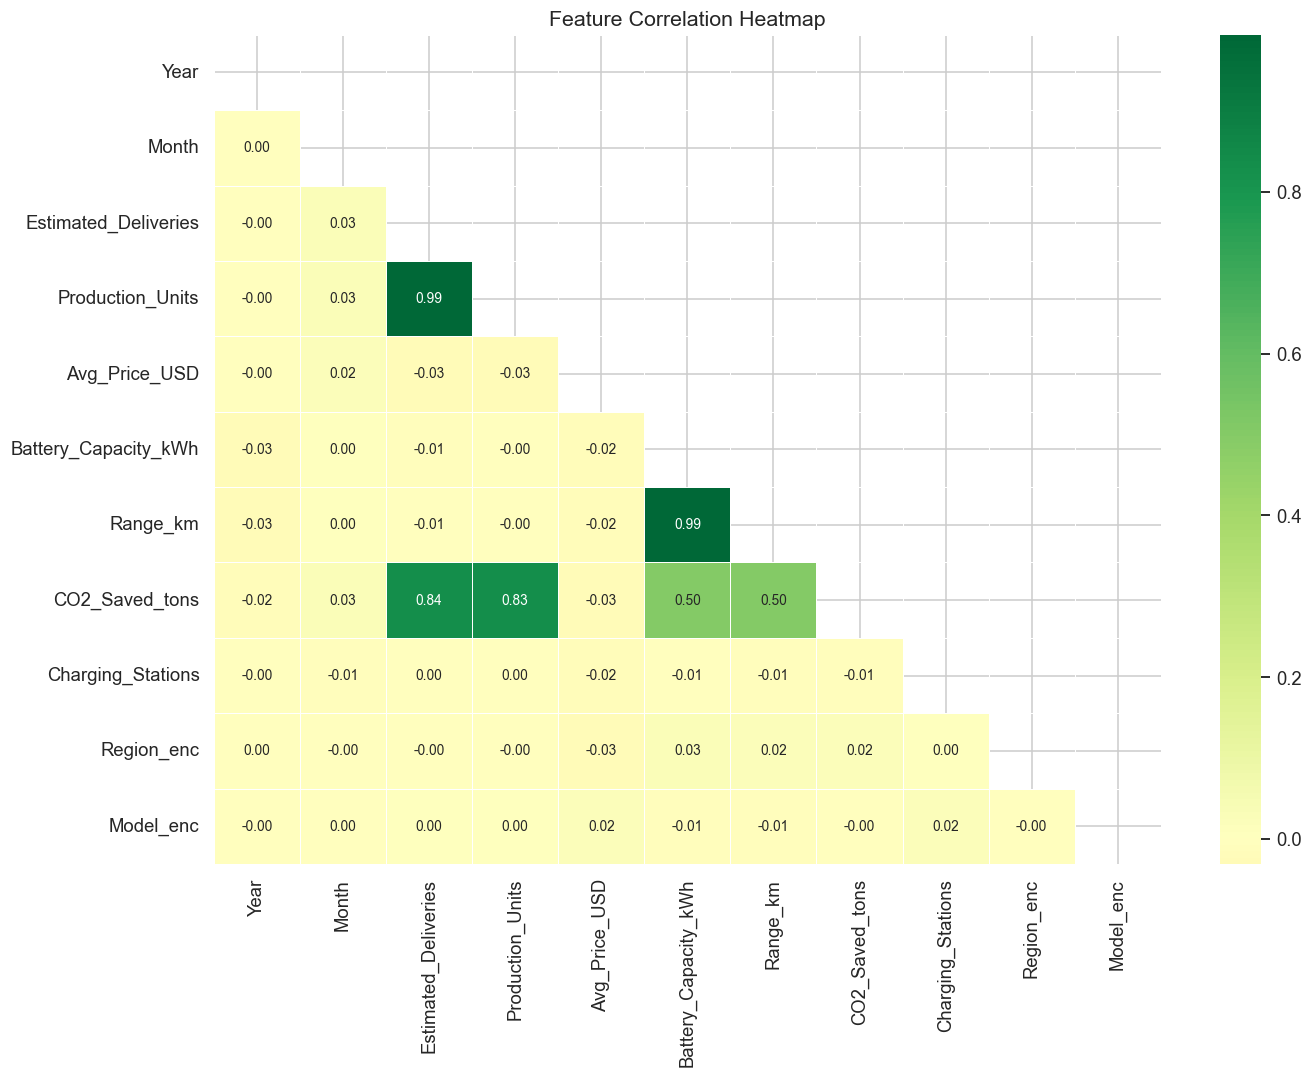


Top correlations with Avg_Price_USD:
Region_enc             0.03
Production_Units       0.03
CO2_Saved_tons         0.03
Estimated_Deliveries   0.03
Month                  0.02
Model_enc              0.02
Battery_Capacity_kWh   0.02
Range_km               0.02
Name: Avg_Price_USD, dtype: float64


In [48]:
corr_cols = ['Year','Month','Estimated_Deliveries','Production_Units','Avg_Price_USD',
             'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations',
             'Region_enc','Model_enc']

corr_matrix = df_ml[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout(); plt.show()

print("\nTop correlations with Avg_Price_USD:")
top_corr = corr_matrix['Avg_Price_USD'].drop('Avg_Price_USD').abs().sort_values(ascending=False)
print(top_corr.head(8))


### 3.6 Delivery Heatmap: Year × Month

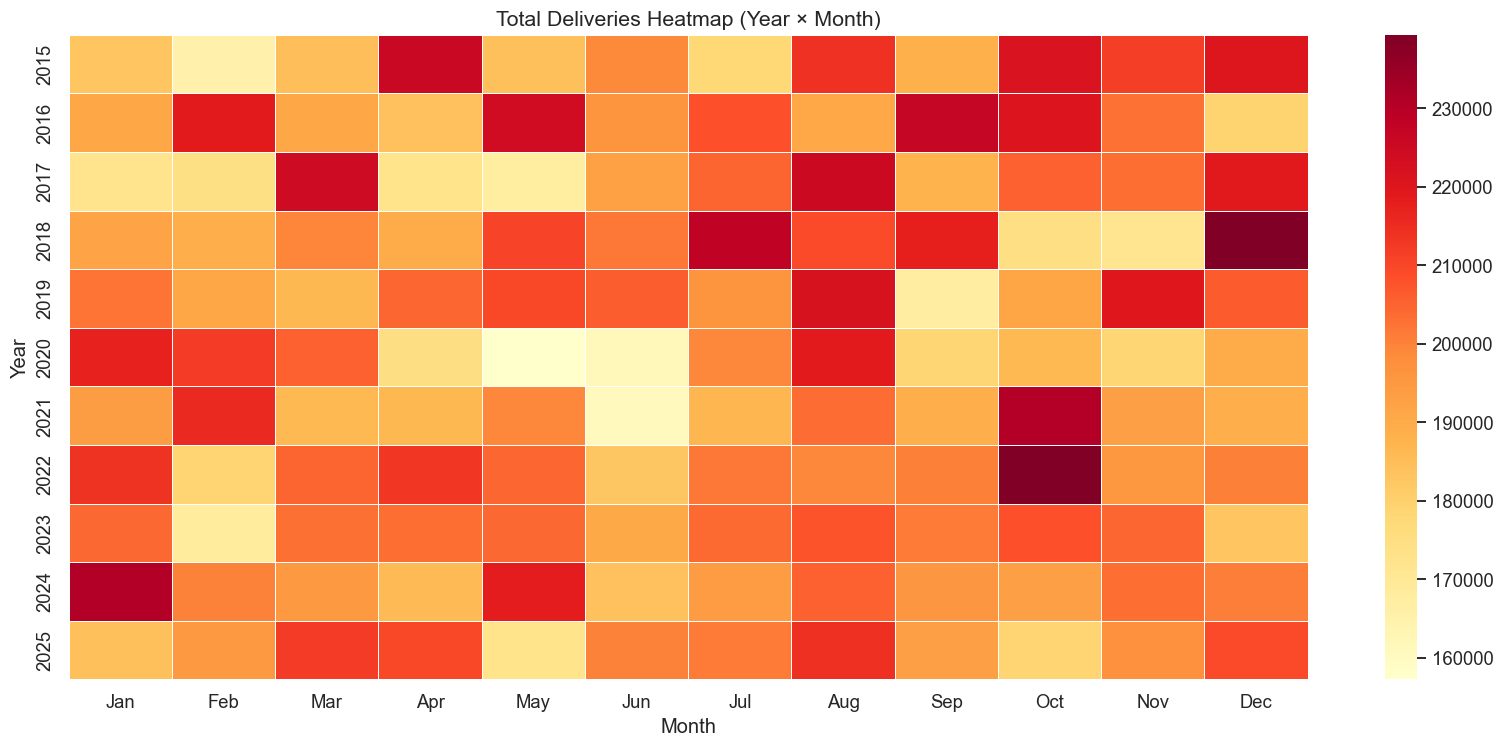

In [49]:
pivot = df_clean.groupby(['Year','Month'])['Estimated_Deliveries'].sum().unstack()
fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(pivot, cmap='YlOrRd', fmt='.0f', linewidths=0.4, ax=ax,
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Total Deliveries Heatmap (Year × Month)', fontsize=14)
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout(); plt.show()


## 4. Feature Engineering

In [50]:
df_fe = df_ml.copy()

# ── Temporal features ──
df_fe['Quarter']        = ((df_fe['Month'] - 1) // 3) + 1
df_fe['Is_Q4']          = (df_fe['Quarter'] == 4).astype(int)
df_fe['Month_sin']      = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_cos']      = np.cos(2 * np.pi * df_fe['Month'] / 12)
df_fe['Years_Since_2015'] = df_fe['Year'] - 2015

# ── Price-engineering ──
df_fe['Price_Per_kWh']  = df_fe['Avg_Price_USD'] / df_fe['Battery_Capacity_kWh']
df_fe['Price_Per_km']   = df_fe['Avg_Price_USD'] / df_fe['Range_km']

# ── Efficiency ──
df_fe['kWh_Per_km']     = df_fe['Battery_Capacity_kWh'] / df_fe['Range_km']
df_fe['CO2_Per_Delivery']= df_fe['CO2_Saved_tons'] / (df_fe['Estimated_Deliveries'] + 1)

# ── Supply efficiency ──
df_fe['Delivery_Rate']  = df_fe['Estimated_Deliveries'] / (df_fe['Production_Units'] + 1)
df_fe['Stations_Per_Delivery'] = df_fe['Charging_Stations'] / (df_fe['Estimated_Deliveries'] + 1)

# ── Interaction terms ──
df_fe['Range_x_Battery']= df_fe['Range_km'] * df_fe['Battery_Capacity_kWh']
df_fe['Model_x_Year']   = df_fe['Model_enc'] * df_fe['Year']

new_feats = ['Quarter','Is_Q4','Month_sin','Month_cos','Years_Since_2015',
             'Price_Per_kWh','Price_Per_km','kWh_Per_km','CO2_Per_Delivery',
             'Delivery_Rate','Stations_Per_Delivery','Range_x_Battery','Model_x_Year']

print(f" {len(new_feats)} new features engineered:")
print(df_fe[new_feats].describe().T[['mean','std','min','max']].round(3))


 13 new features engineered:
                           mean       std       min       max
Quarter                    2.50      1.12      1.00      4.00
Is_Q4                      0.25      0.43      0.00      1.00
Month_sin                 -0.00      0.71     -1.00      1.00
Month_cos                 -0.00      0.71     -1.00      1.00
Years_Since_2015           5.00      3.16      0.00     10.00
Price_Per_kWh          1,033.35    353.26    417.08  1,999.42
Price_Per_km             180.05     61.89     69.90    359.38
kWh_Per_km                 0.17      0.00      0.17      0.18
CO2_Per_Delivery           0.07      0.02      0.05      0.11
Delivery_Rate              0.93      0.04      0.86      1.00
Stations_Per_Delivery      1.47      6.06      0.16    225.92
Range_x_Battery       46,055.34 21,875.61 19,800.00 86,280.00
Model_x_Year           4,040.00  2,857.26      0.00  8,100.00


### 4.1 Feature Importance (Quick Preview via Random Forest)

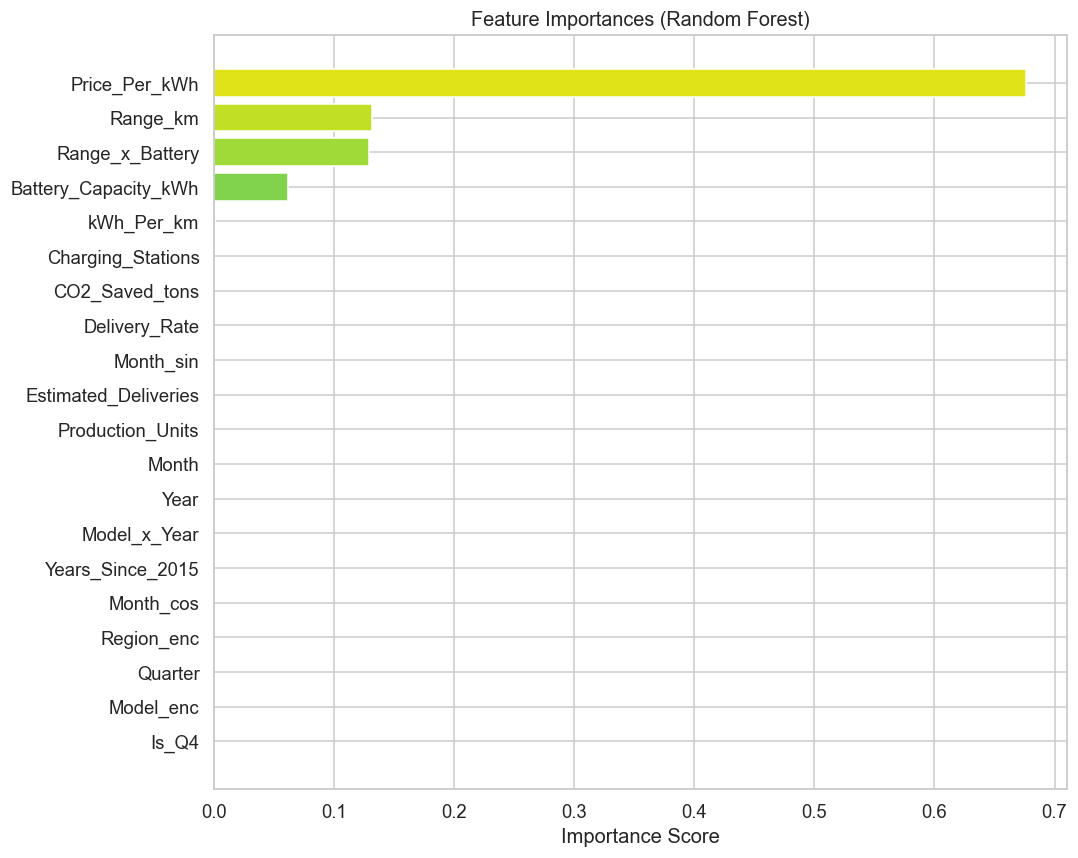


Top 10 most important features:
             Feature  Importance
       Price_Per_kWh        0.68
            Range_km        0.13
     Range_x_Battery        0.13
Battery_Capacity_kWh        0.06
          kWh_Per_km        0.00
   Charging_Stations        0.00
      CO2_Saved_tons        0.00
       Delivery_Rate        0.00
           Month_sin        0.00
Estimated_Deliveries        0.00


In [51]:
FEATURES = ['Year','Month','Quarter','Is_Q4','Month_sin','Month_cos',
            'Years_Since_2015','Battery_Capacity_kWh','Range_km',
            'CO2_Saved_tons','Charging_Stations','Estimated_Deliveries',
            'Production_Units','Delivery_Rate','kWh_Per_km','Price_Per_kWh',
            'Range_x_Battery','Model_x_Year','Region_enc','Model_enc']
TARGET = 'Avg_Price_USD'

X_all = df_fe[FEATURES].fillna(0)
y_all = df_fe[TARGET]

rf_quick = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_quick.fit(X_all, y_all)

importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_quick.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_ = sns.color_palette('viridis', len(importance_df))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors_, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

print("\nTop 10 most important features:")
print(importance_df.tail(10)[['Feature','Importance']].iloc[::-1].to_string(index=False))


## 5. Regression Modeling
### 5.1 Train / Test Split & Scaling

In [52]:
X = df_fe[FEATURES].fillna(0)
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Target range : ${y.min():,.0f}  –  ${y.max():,.0f}")


Training set : (2112, 20)
Test set     : (528, 20)
Target range : $50,004  –  $119,965


### 5.2 Baseline Models

In [53]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=1.0),
    'ElasticNet'        : ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=42),
    'Extra Trees'       : ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    # Linear models use scaled data; tree-based use raw
    X_tr = X_train_s if name in ('Linear Regression','Ridge','Lasso','ElasticNet') else X_train
    X_te = X_test_s  if name in ('Linear Regression','Ridge','Lasso','ElasticNet') else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    results.append({
        'Model' : name,
        'MAE'   : mean_absolute_error(y_test, y_pred),
        'RMSE'  : np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE'  : mean_absolute_percentage_error(y_test, y_pred) * 100,
        'R²'    : r2_score(y_test, y_pred),
    })
    print(f"{name:<22}  R²={results[-1]['R²']:.4f}  RMSE={results[-1]['RMSE']:,.0f}  MAE={results[-1]['MAE']:,.0f}")

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n── Ranking by R² ──")
print(results_df.to_string(index=False))


Linear Regression       R²=0.9416  RMSE=4,692  MAE=3,492
Ridge                   R²=0.9420  RMSE=4,678  MAE=3,518
Lasso                   R²=0.9395  RMSE=4,777  MAE=3,552
ElasticNet              R²=0.6508  RMSE=11,475  MAE=9,743
Decision Tree           R²=0.9893  RMSE=2,008  MAE=836
Random Forest           R²=0.9988  RMSE=659  MAE=234
Gradient Boosting       R²=0.9970  RMSE=1,059  MAE=746
Extra Trees             R²=1.0000  RMSE=75  MAE=57

── Ranking by R² ──
            Model      MAE      RMSE  MAPE   R²
      Extra Trees    57.31     74.85  0.07 1.00
    Random Forest   234.00    658.56  0.29 1.00
Gradient Boosting   746.36  1,058.50  0.92 1.00
    Decision Tree   836.12  2,008.35  0.99 0.99
            Ridge 3,518.00  4,678.33  4.60 0.94
Linear Regression 3,491.89  4,692.09  4.61 0.94
            Lasso 3,551.81  4,776.95  4.68 0.94
       ElasticNet 9,742.81 11,474.99 12.65 0.65


### 5.3 Model Comparison Visualization

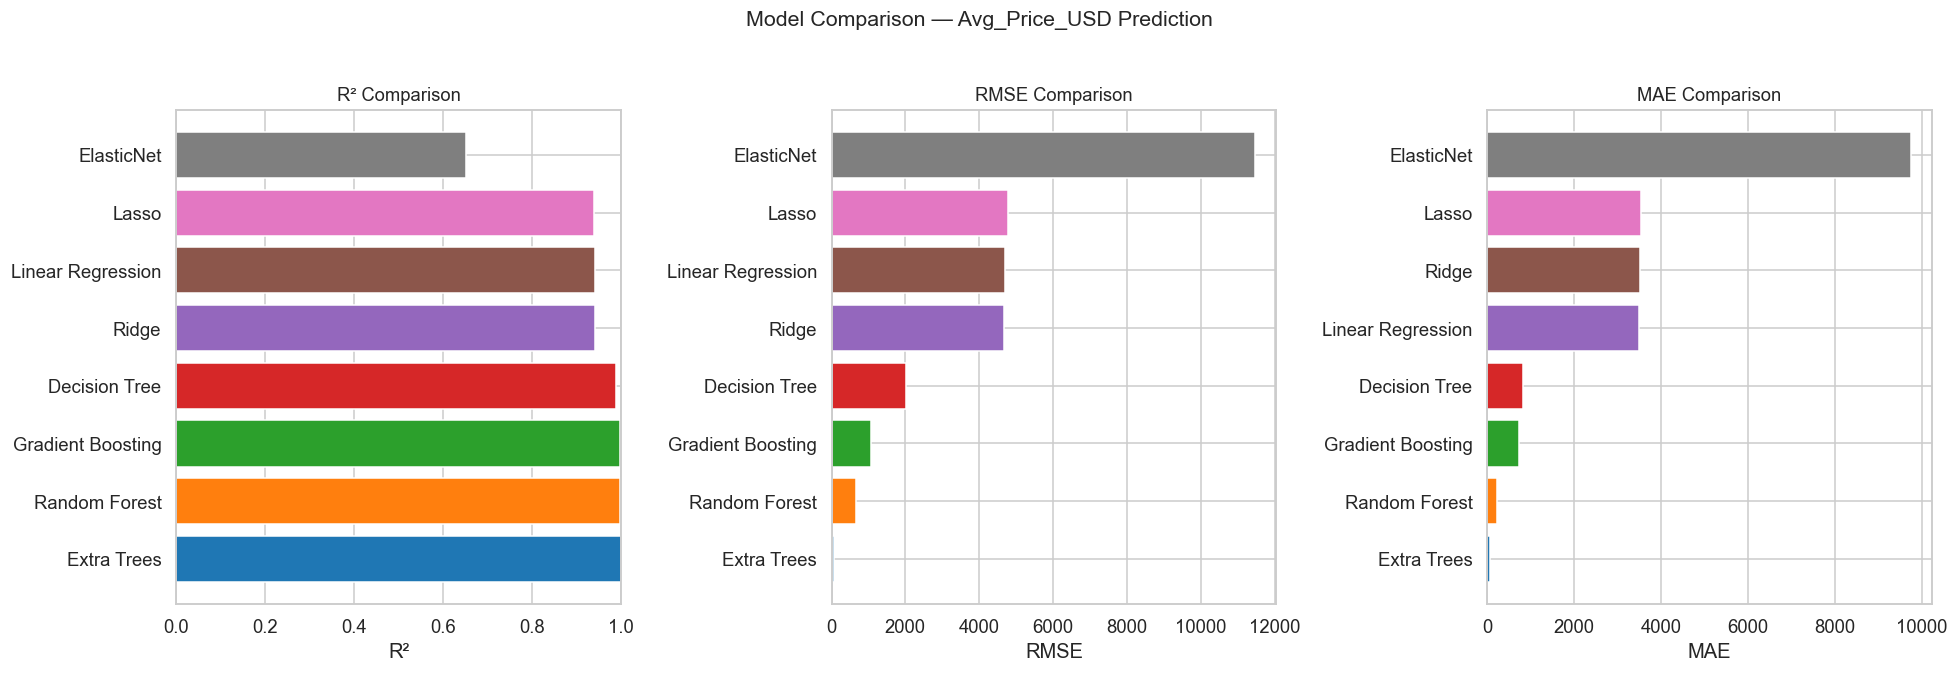

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['R²', 'RMSE', 'MAE']
palette = sns.color_palette('tab10', len(results_df))

for ax, metric in zip(axes, metrics):
    order = results_df.sort_values(metric, ascending=(metric != 'R²'))
    colors_ = palette[:len(order)]
    ax.barh(order['Model'], order[metric], color=colors_, edgecolor='white')
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_xlabel(metric)
    if metric == 'R²':
        ax.set_xlim(0, 1)

plt.suptitle('Model Comparison — Avg_Price_USD Prediction', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


### 5.4 Cross-Validation (5-Fold)

In [55]:
cv_results = []
for name, model in models.items():
    X_cv = X_train_s if name in ('Linear Regression','Ridge','Lasso','ElasticNet') else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results.append({'Model': name, 'CV_R²_Mean': scores.mean(), 'CV_R²_Std': scores.std()})
    print(f"{name:<22}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('CV_R²_Mean', ascending=False)
print("\nBest CV model:", cv_df.iloc[0]['Model'])


Linear Regression       CV R² = 0.9458 ± 0.0029
Ridge                   CV R² = 0.9454 ± 0.0026
Lasso                   CV R² = 0.9451 ± 0.0034
ElasticNet              CV R² = 0.6542 ± 0.0110
Decision Tree           CV R² = 0.9953 ± 0.0037
Random Forest           CV R² = 0.9989 ± 0.0007
Gradient Boosting       CV R² = 0.9972 ± 0.0009
Extra Trees             CV R² = 1.0000 ± 0.0000

Best CV model: Extra Trees


## 6. Hyperparameter Tuning
### 6.1 Grid Search on Gradient Boosting

In [56]:
param_grid_gb = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.1, 0.15],
    'subsample'     : [0.8, 1.0],
}

gb_base = GradientBoostingRegressor(random_state=42)
gs_gb = GridSearchCV(gb_base, param_grid_gb, cv=5, scoring='r2',
                     n_jobs=-1, verbose=0, refit=True)
gs_gb.fit(X_train, y_train)

print("Best GB params :", gs_gb.best_params_)
print(f"Best CV R²     : {gs_gb.best_score_:.4f}")

y_pred_gb = gs_gb.best_estimator_.predict(X_test)
print(f"\nTest R²  : {r2_score(y_test, y_pred_gb):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):,.0f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_gb):,.0f}")


Best GB params : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV R²     : 0.9993

Test R²  : 0.9993
Test RMSE: 509
Test MAE : 323


### 6.2 Grid Search on Random Forest

In [57]:
param_grid_rf = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [None, 10, 20],
    'max_features' : ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
gs_rf = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='r2',
                     n_jobs=-1, verbose=0, refit=True)
gs_rf.fit(X_train, y_train)

print("Best RF params :", gs_rf.best_params_)
print(f"Best CV R²     : {gs_rf.best_score_:.4f}")

y_pred_rf = gs_rf.best_estimator_.predict(X_test)
print(f"\nTest R²  : {r2_score(y_test, y_pred_rf):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_rf):,.0f}")


Best RF params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²     : 0.8859

Test R²  : 0.8987
Test RMSE: 6,181
Test MAE : 5,004


### 6.3 Best Model: Actual vs Predicted

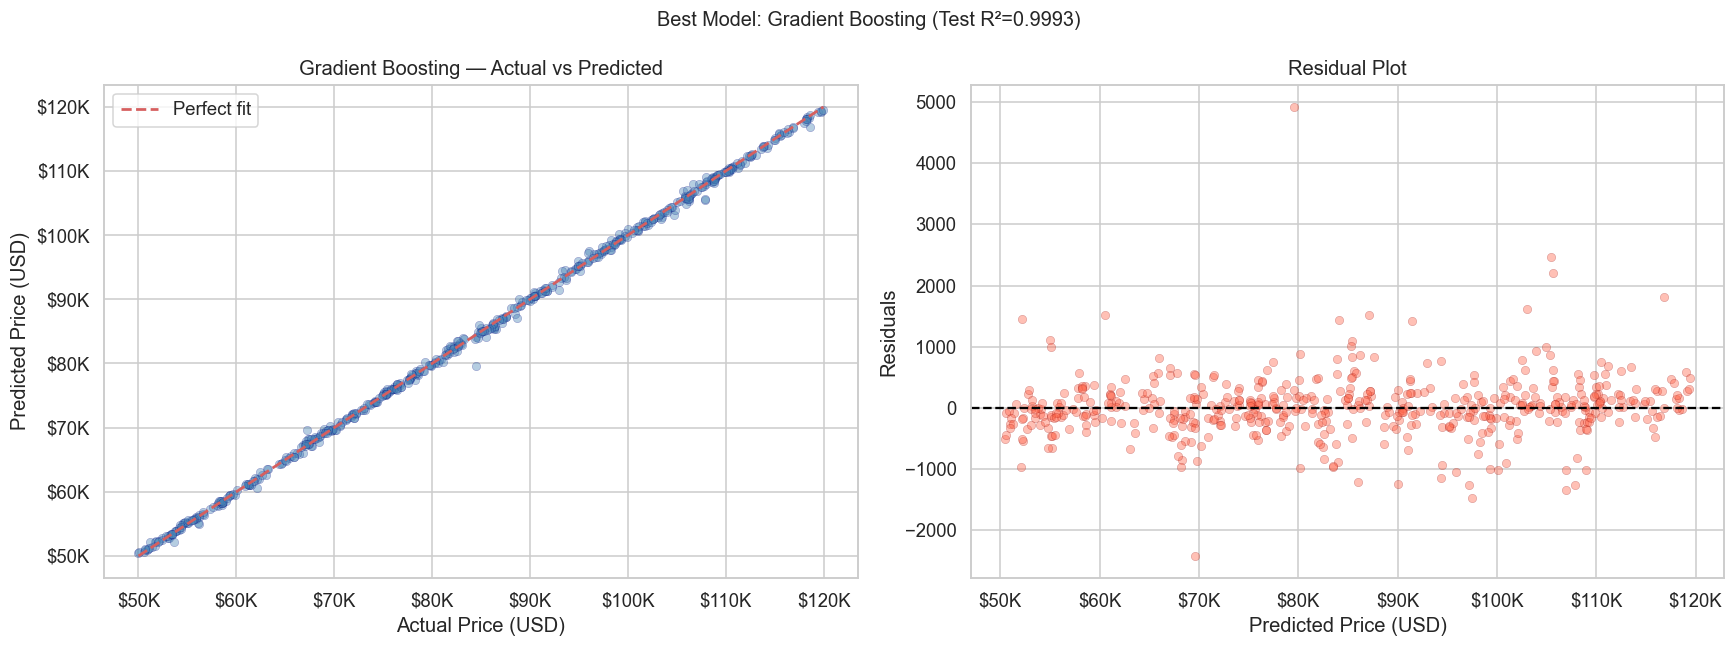

In [58]:
# Choose whichever tuned model performs better
best_pred = y_pred_gb if r2_score(y_test, y_pred_gb) >= r2_score(y_test, y_pred_rf) else y_pred_rf
best_name = 'Gradient Boosting' if r2_score(y_test, y_pred_gb) >= r2_score(y_test, y_pred_rf) else 'Random Forest'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(y_test, best_pred, alpha=0.4, edgecolors='navy', linewidths=0.3,
                color='steelblue', s=30)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx],'r--', linewidth=1.8, label='Perfect fit')
axes[0].set_xlabel('Actual Price (USD)'); axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title(f'{best_name} — Actual vs Predicted')
axes[0].legend(); axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

# Residuals
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4, edgecolors='darkred', linewidths=0.3,
                color='tomato', s=30)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Price (USD)'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

plt.suptitle(f'Best Model: {best_name} (Test R²={r2_score(y_test, best_pred):.4f})', fontsize=13)
plt.tight_layout(); plt.show()


## 7. Time Series Forecasting
### 7.1 Build Monthly Time Series

In [59]:
# Aggregate all regions & models to a single monthly delivery series
ts = (df_clean
      .groupby('Date')['Estimated_Deliveries']
      .sum()
      .sort_index()
      .asfreq('MS'))   

print("Time series shape:", ts.shape)
print("Date range        :", ts.index[0].strftime('%b %Y'), "→", ts.index[-1].strftime('%b %Y'))
print("\nFirst 5 values:")
print(ts.head())


Time series shape: (132,)
Date range        : Jan 2015 → Dec 2025

First 5 values:
Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Freq: MS, Name: Estimated_Deliveries, dtype: int64


### 7.2 Time Series Plot

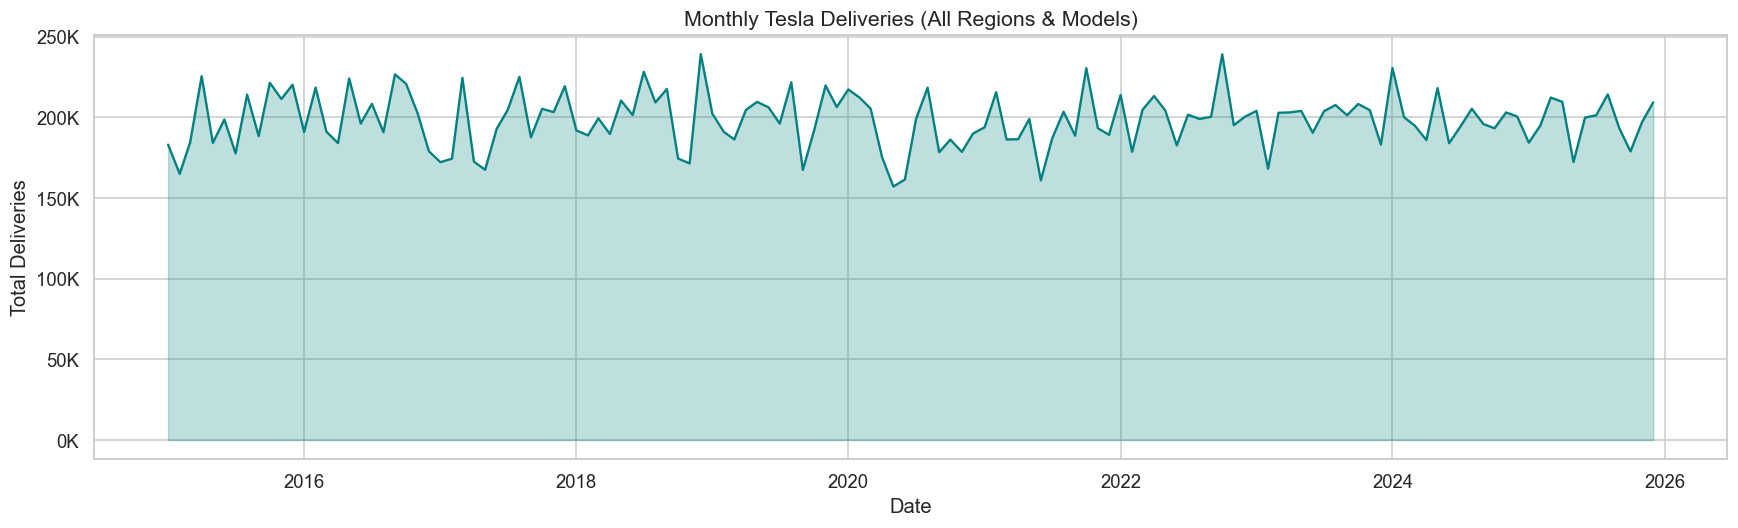

In [60]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(ts.index, ts.values, alpha=0.25, color='teal')
ax.plot(ts.index, ts.values, color='teal', linewidth=1.5)
ax.set_title('Monthly Tesla Deliveries (All Regions & Models)', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Total Deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
plt.tight_layout(); plt.show()


### 7.3 Seasonal Decomposition

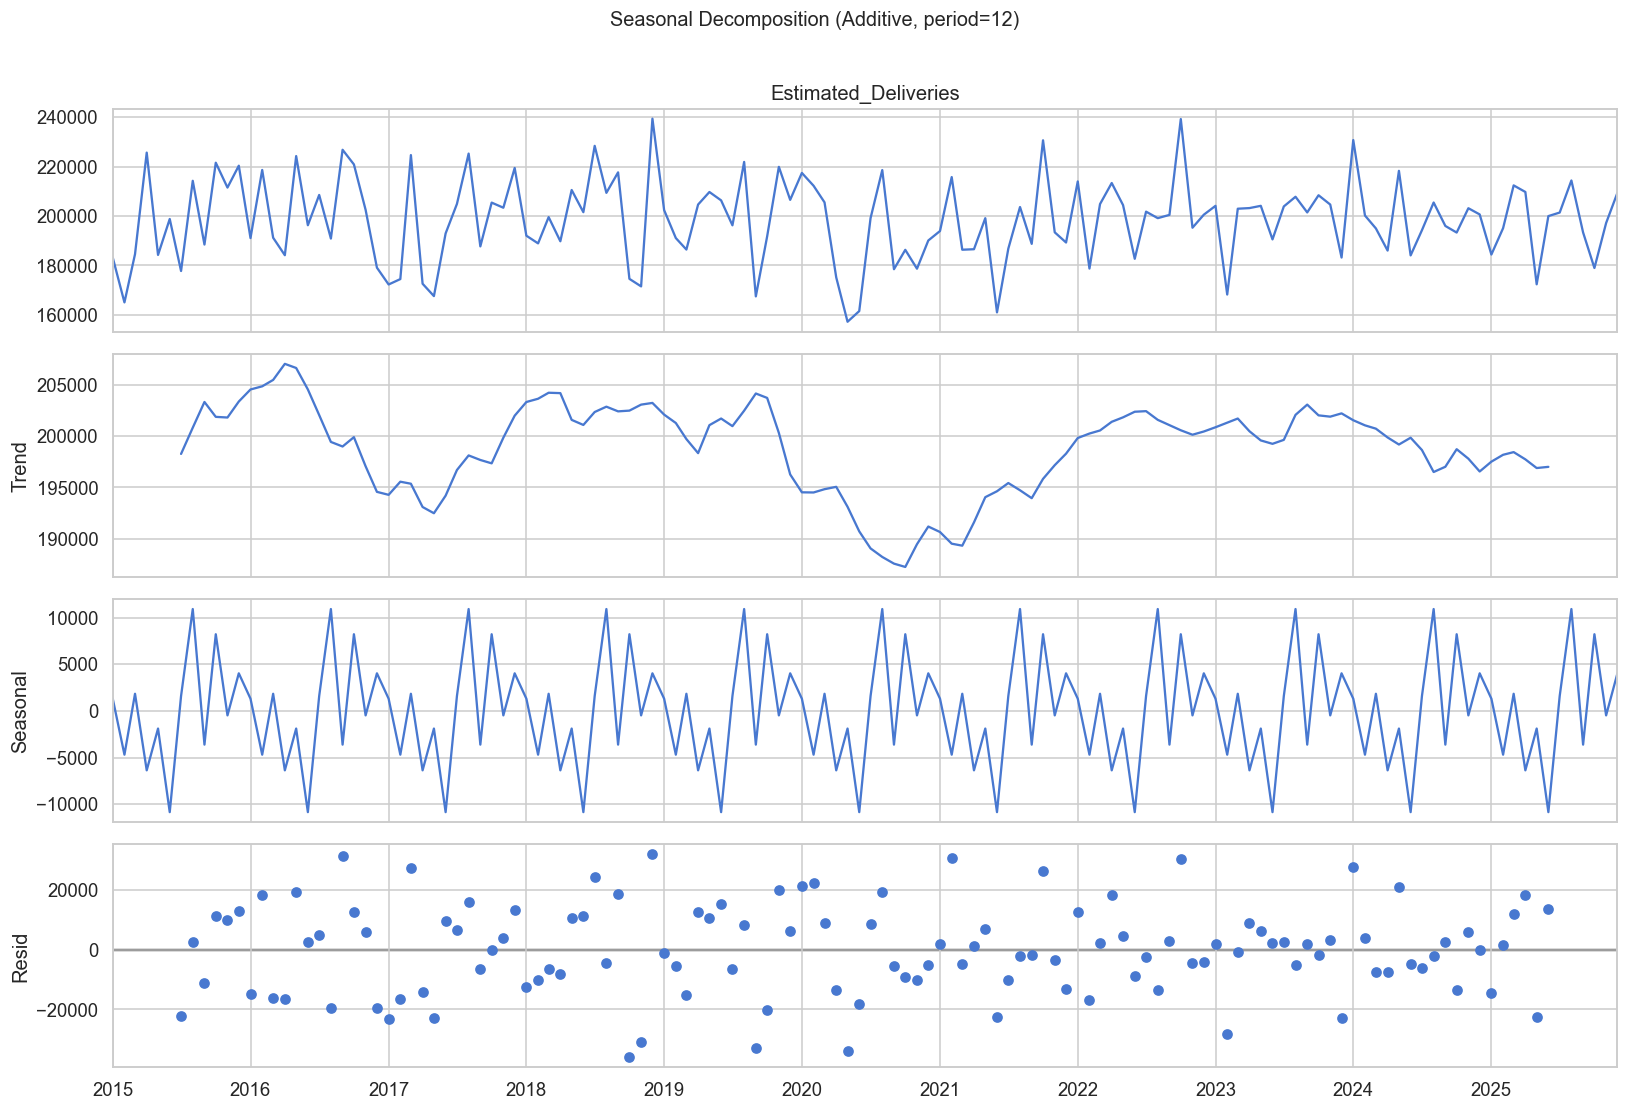

In [61]:
decomp = seasonal_decompose(ts, model='additive', period=12)

fig = decomp.plot()
fig.set_size_inches(15, 10)
fig.suptitle('Seasonal Decomposition (Additive, period=12)', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()


### 7.4 Stationarity Test (ADF)

In [62]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical vals : {result[4]}")
    if result[1] < 0.05:
        print("   Series is STATIONARY (p < 0.05)")
    else:
        print("   Series is NON-STATIONARY (p ≥ 0.05) — differencing needed")
    return result[1]

p_raw  = adf_test(ts, 'Raw Deliveries')
ts_diff = ts.diff().dropna()
p_diff = adf_test(ts_diff, 'First-Differenced Deliveries')



ADF Test — Raw Deliveries
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Critical vals : {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
   Series is STATIONARY (p < 0.05)

ADF Test — First-Differenced Deliveries
  ADF Statistic : -7.0101
  p-value       : 0.0000
  Critical vals : {'1%': np.float64(-3.4846672514209773), '5%': np.float64(-2.8853397507076006), '10%': np.float64(-2.5794629869786503)}
   Series is STATIONARY (p < 0.05)


### 7.5 ACF & PACF Plots

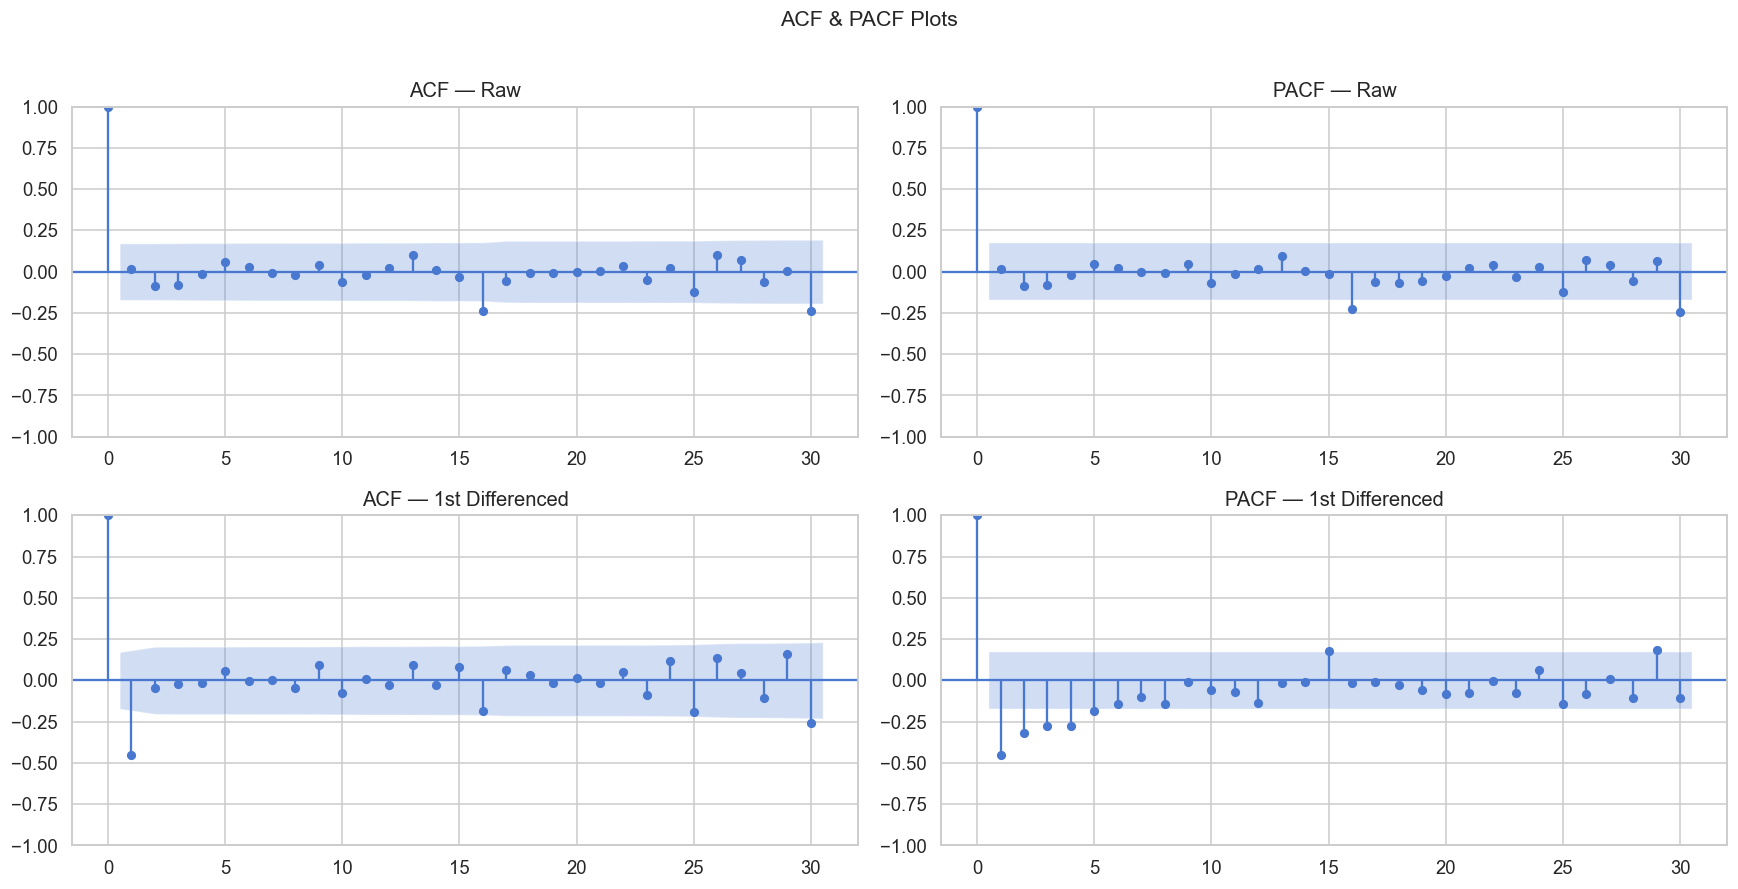

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(ts,      ax=axes[0,0], lags=30, title='ACF — Raw')
plot_pacf(ts,     ax=axes[0,1], lags=30, title='PACF — Raw')
plot_acf(ts_diff, ax=axes[1,0], lags=30, title='ACF — 1st Differenced')
plot_pacf(ts_diff,ax=axes[1,1], lags=30, title='PACF — 1st Differenced')

plt.suptitle('ACF & PACF Plots', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 7.6 Train/Test Split for Forecasting (80/20)

In [64]:
split_idx = int(len(ts) * 0.8)
ts_train = ts.iloc[:split_idx]
ts_test  = ts.iloc[split_idx:]

print(f"Training: {ts_train.index[0].strftime('%b %Y')} → {ts_train.index[-1].strftime('%b %Y')}  ({len(ts_train)} months)")
print(f"Test    : {ts_test.index[0].strftime('%b %Y')}  → {ts_test.index[-1].strftime('%b %Y')}  ({len(ts_test)} months)")


Training: Jan 2015 → Sep 2023  (105 months)
Test    : Oct 2023  → Dec 2025  (27 months)


### 7.7 ARIMA Model

In [65]:
# Order selected from ACF/PACF: (1,1,1) seasonal with period 12
arima_model = ARIMA(ts_train, order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 12))
arima_fit = arima_model.fit()

print(arima_fit.summary().tables[0])

arima_pred = arima_fit.forecast(steps=len(ts_test))
arima_pred.index = ts_test.index

mae_arima  = mean_absolute_error(ts_test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(ts_test, arima_pred))
mape_arima = mean_absolute_percentage_error(ts_test, arima_pred) * 100

print(f"\nARIMA Test MAE  : {mae_arima:,.0f}")
print(f"ARIMA Test RMSE : {rmse_arima:,.0f}")
print(f"ARIMA Test MAPE : {mape_arima:.2f}%")


                                    SARIMAX Results                                     
Dep. Variable:             Estimated_Deliveries   No. Observations:                  105
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1062.394
Date:                          Mon, 01 Jun 2026   AIC                           2134.788
Time:                                  19:07:42   BIC                           2147.397
Sample:                              01-01-2015   HQIC                          2139.877
                                   - 09-01-2023                                         
Covariance Type:                            opg                                         

ARIMA Test MAE  : 23,857
ARIMA Test RMSE : 27,749
ARIMA Test MAPE : 12.35%


### 7.8 Holt-Winters Exponential Smoothing

In [66]:
hw_model = ExponentialSmoothing(
    ts_train, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit(optimized=True)

hw_pred = hw_fit.forecast(len(ts_test))
hw_pred.index = ts_test.index

mae_hw  = mean_absolute_error(ts_test, hw_pred)
rmse_hw = np.sqrt(mean_squared_error(ts_test, hw_pred))
mape_hw = mean_absolute_percentage_error(ts_test, hw_pred) * 100

print(f"Holt-Winters Test MAE  : {mae_hw:,.0f}")
print(f"Holt-Winters Test RMSE : {rmse_hw:,.0f}")
print(f"Holt-Winters Test MAPE : {mape_hw:.2f}%")


Holt-Winters Test MAE  : 11,012
Holt-Winters Test RMSE : 15,050
Holt-Winters Test MAPE : 5.53%


### 7.9 Forecast Comparison Plot

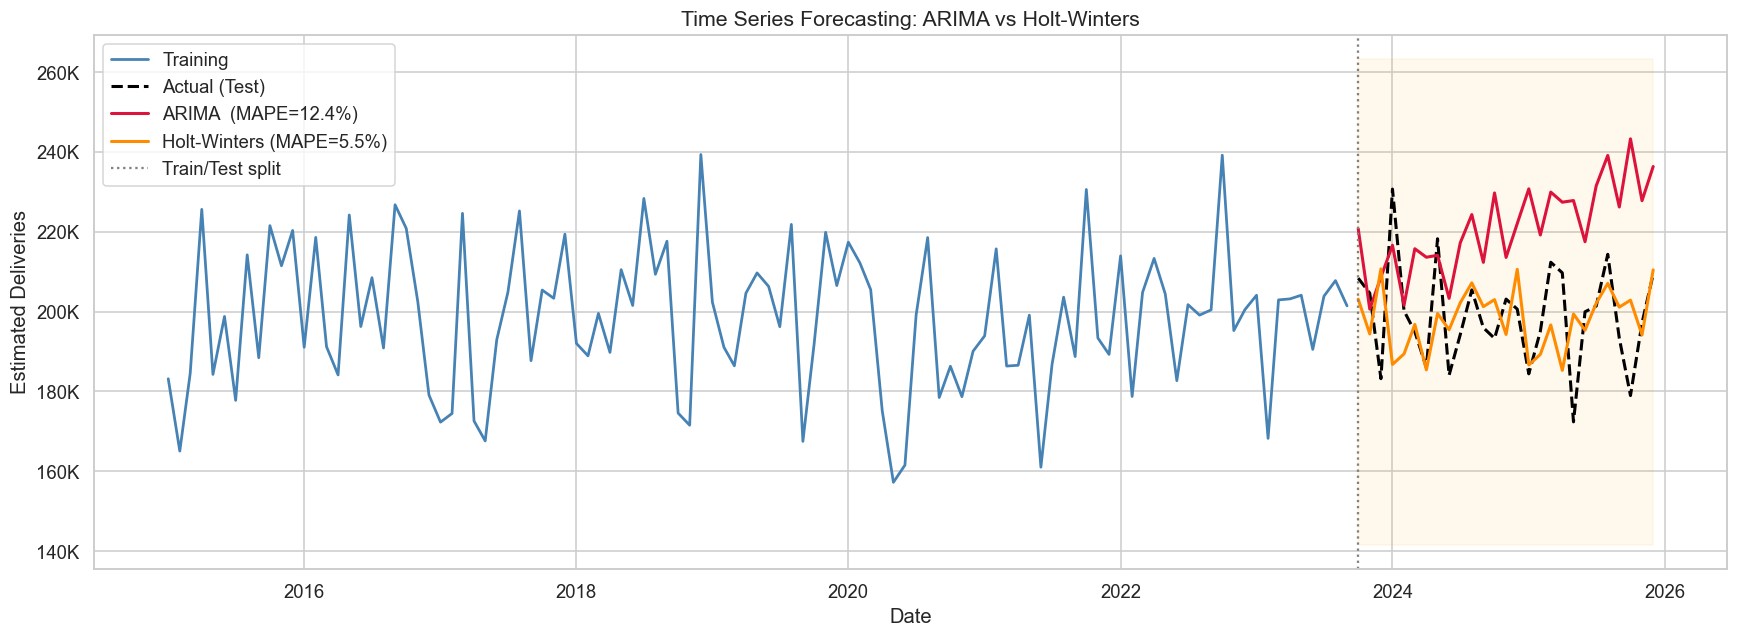

In [67]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(ts_train.index, ts_train.values, label='Training', color='steelblue', linewidth=1.8)
ax.plot(ts_test.index,  ts_test.values,  label='Actual (Test)', color='black',
        linewidth=2, linestyle='--')
ax.plot(arima_pred.index, arima_pred.values, label=f'ARIMA  (MAPE={mape_arima:.1f}%)',
        color='crimson', linewidth=2)
ax.plot(hw_pred.index, hw_pred.values, label=f'Holt-Winters (MAPE={mape_hw:.1f}%)',
        color='darkorange', linewidth=2)

ax.axvline(ts_test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.fill_betweenx([ts.min()*0.9, ts.max()*1.1],
                  ts_test.index[0], ts_test.index[-1], alpha=0.07, color='orange')

ax.set_title('Time Series Forecasting: ARIMA vs Holt-Winters', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Estimated Deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.legend(); plt.tight_layout(); plt.show()


### 7.10 Forecast Metrics Summary

In [68]:
fc_summary = pd.DataFrame([
    {'Model': 'ARIMA(1,1,1)×(1,1,1,12)', 'MAE': mae_arima, 'RMSE': rmse_arima, 'MAPE%': mape_arima},
    {'Model': 'Holt-Winters (Add+Add)',   'MAE': mae_hw,    'RMSE': rmse_hw,    'MAPE%': mape_hw},
]).sort_values('MAPE%')
print(fc_summary.to_string(index=False))

best_fc = fc_summary.iloc[0]['Model']
print(f"\n Best forecasting model: {best_fc}")


                  Model       MAE      RMSE  MAPE%
 Holt-Winters (Add+Add) 11,011.89 15,049.85   5.53
ARIMA(1,1,1)×(1,1,1,12) 23,856.82 27,749.18  12.35

 Best forecasting model: Holt-Winters (Add+Add)


### 7.11 Future Forecast (2026)

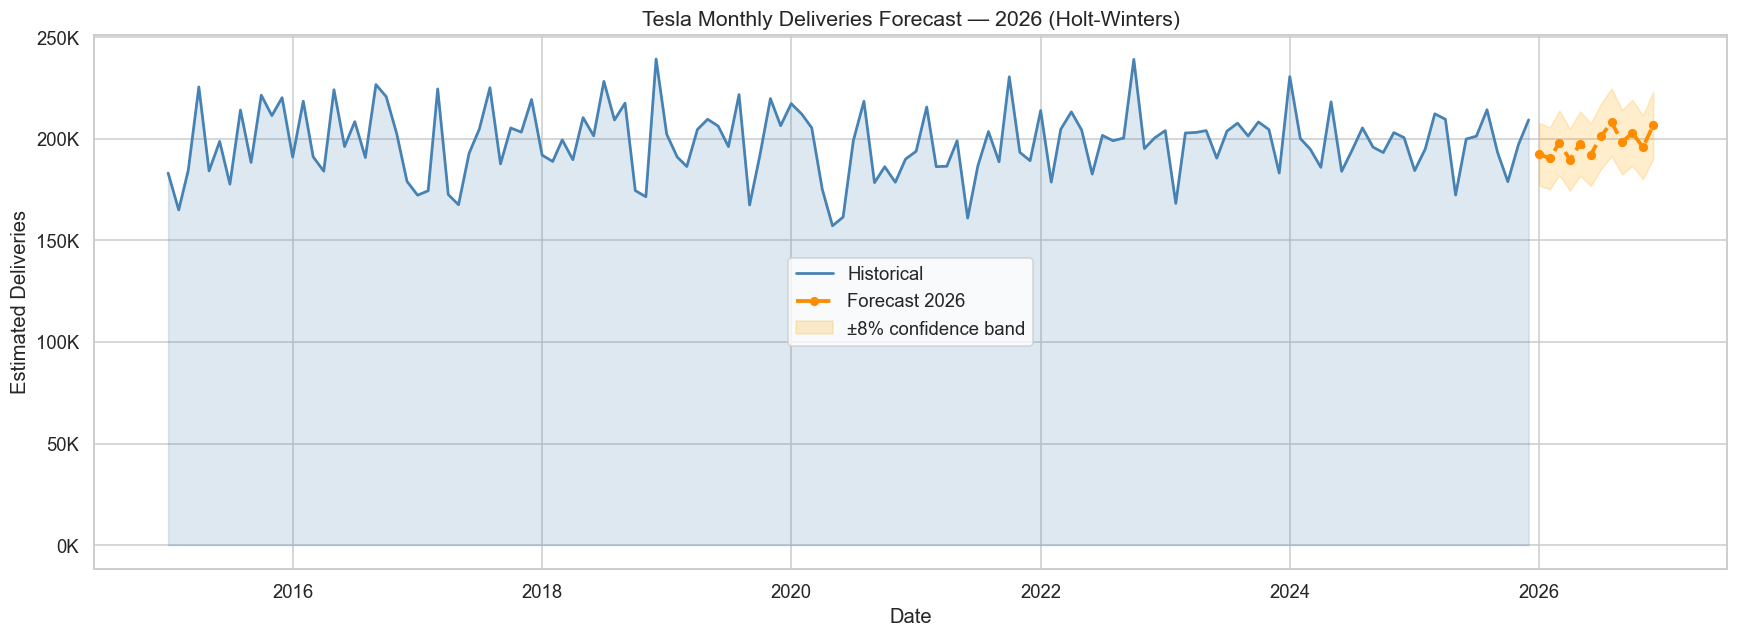


2026 Monthly Forecast:
  Jan 2026 :    192,503 deliveries
  Feb 2026 :    190,434 deliveries
  Mar 2026 :    198,070 deliveries
  Apr 2026 :    189,793 deliveries
  May 2026 :    197,736 deliveries
  Jun 2026 :    192,219 deliveries
  Jul 2026 :    201,205 deliveries
  Aug 2026 :    208,205 deliveries
  Sep 2026 :    198,374 deliveries
  Oct 2026 :    203,016 deliveries
  Nov 2026 :    195,870 deliveries
  Dec 2026 :    206,738 deliveries


In [69]:
# Refit best model on full data and forecast 12 months ahead
final_hw = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12)
final_hw_fit = final_hw.fit(optimized=True)

forecast_2026 = final_hw_fit.forecast(12)
forecast_2026.index = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(ts.index, ts.values, alpha=0.18, color='steelblue')
ax.plot(ts.index, ts.values, label='Historical', color='steelblue', linewidth=1.8)
ax.plot(forecast_2026.index, forecast_2026.values, label='Forecast 2026',
        color='darkorange', linewidth=2.5, linestyle='--', marker='o', markersize=5)

ax.fill_between(forecast_2026.index,
                forecast_2026.values * 0.92,
                forecast_2026.values * 1.08,
                alpha=0.2, color='orange', label='±8% confidence band')

ax.set_title('Tesla Monthly Deliveries Forecast — 2026 (Holt-Winters)', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Estimated Deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.legend(); plt.tight_layout(); plt.show()

print("\n2026 Monthly Forecast:")
for d, v in forecast_2026.items():
    print(f"  {d.strftime('%b %Y')} : {v:>10,.0f} deliveries")


## 8. Pipeline Summary & Key Findings

In [70]:
print("=" * 65)
print("       TESLA DELIVERIES — END-TO-END ML PIPELINE SUMMARY")
print("=" * 65)

print("\n DATASET")
print(f"  Records  : {df.shape[0]:,}  |  Features: {df.shape[1]}")
print(f"  Period   : 2015 – 2025  |  Models: {df['Model'].nunique()}")
print(f"  Regions  : {', '.join(df['Region'].unique())}")

print("\n PREPROCESSING")
print(f"  Missing values : 0  |  Duplicates removed: {df.duplicated().sum()}")
print("  Encodings      : LabelEncoder (Region, Model, Source_Type)")
print("  Outliers       : Detected via IQR, visually inspected")

print(f"\n  FEATURE ENGINEERING  — {len(new_feats)} new features")
print("  Temporal, cyclical, efficiency, interaction terms")

print("\n REGRESSION — Target: Avg_Price_USD")
best_reg = results_df.iloc[0]
print(f"  Best model      : {best_reg['Model']}")
print(f"  Test R²         : {best_reg['R²']:.4f}")
print(f"  Test RMSE       : ${best_reg['RMSE']:,.0f}")
print(f"  Test MAE        : ${best_reg['MAE']:,.0f}")

print("\n HYPERPARAMETER TUNING")
print(f"  GridSearchCV (5-fold) on GradientBoosting & RandomForest")
print(f"  Best GBT R² : {r2_score(y_test, y_pred_gb):.4f}")
print(f"  Best RF  R² : {r2_score(y_test, y_pred_rf):.4f}")

print("\nTIME SERIES FORECASTING — Target: Estimated_Deliveries")
print(fc_summary.to_string(index=False))
print(f"\n  Best forecaster : {best_fc}")
print("  2026 forecast generated (Holt-Winters, ±8% CI band)")
print("=" * 65)
print("Pipeline complete!")


       TESLA DELIVERIES — END-TO-END ML PIPELINE SUMMARY

 DATASET
  Records  : 2,640  |  Features: 12
  Period   : 2015 – 2025  |  Models: 5
  Regions  : Europe, Asia, North America, Middle East

 PREPROCESSING
  Missing values : 0  |  Duplicates removed: 0
  Encodings      : LabelEncoder (Region, Model, Source_Type)
  Outliers       : Detected via IQR, visually inspected

  FEATURE ENGINEERING  — 13 new features
  Temporal, cyclical, efficiency, interaction terms

 REGRESSION — Target: Avg_Price_USD
  Best model      : Extra Trees
  Test R²         : 1.0000
  Test RMSE       : $75
  Test MAE        : $57

 HYPERPARAMETER TUNING
  GridSearchCV (5-fold) on GradientBoosting & RandomForest
  Best GBT R² : 0.9993
  Best RF  R² : 0.8987

TIME SERIES FORECASTING — Target: Estimated_Deliveries
                  Model       MAE      RMSE  MAPE%
 Holt-Winters (Add+Add) 11,011.89 15,049.85   5.53
ARIMA(1,1,1)×(1,1,1,12) 23,856.82 27,749.18  12.35

  Best forecaster : Holt-Winters (Add+Add)
  20